# 📉 Customer Churn Analysis
**Author:** Pius Victor  
**Date:** 01-03-2026  

In this project, I analyze customer churn behavior for a retail company. Churn means customers leaving or stopping use of a service. I'll explore what factors cause customers to leave, and which groups are most at risk.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving churn csv.csv to churn csv (1).csv


## 1. Import Libraries
These are the tools we'll use throughout the project.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Dataset

In [28]:
# Load the dataset
# Upload churn.csv to Colab first using the Files panel on the left
df = pd.read_csv('churn csv (1).csv')

# Preview the first 10 rows
df.head(10)

,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,...,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,...,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,...,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,3,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,...,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,4,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,...,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1
5,5,13,M,PSG1LGF,City,Gold Membership,2016-01-08,No,xxxxxxxx,Gift Vouchers/Coupons,...,433.62,13884.77,24.0,722.27,Yes,No,Yes,Unsolved,No reason specified,0
6,6,21,M,R3CX1EA,Town,Gold Membership,2015-03-19,Yes,CID24708,Gift Vouchers/Coupons,...,55.38,8982.50,28.0,756.21,Yes,No,Yes,Solved in Follow-up,No reason specified,0
7,7,42,M,4UJ1551,NaN,No Membership,2016-07-12,?,CID56614,Credit/Debit Card Offers,...,429.11,44554.82,24.0,568.08,No,Yes,Yes,Unsolved,Poor Product Quality,1
8,8,44,M,0481QNQ,Village,Silver Membership,2016-12-14,No,xxxxxxxx,Without Offers,...,191.07,18362.31,20.0,NaN,Yes,No,Yes,Solved in Follow-up,Poor Customer Service,0
9,9,45,F,ZHP4MCR,Town,No Membership,2016-11-30,No,xxxxxxxx,Gift Vouchers/Coupons,...,97.31,19244.16,28.0,706.23,No,Yes,Yes,No Information Available,Poor Customer Service,1


## 3. Explore the Data
Let's understand the dataset before cleaning and analyzing it.

In [29]:
# Shape of the dataset
print('Shape of dataset:', df.shape)
print()
print('Column info:')
print(df.info())

Shape of dataset: (36992, 24)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    36992 non-null  int64  
 1   age                           36992 non-null  int64  
 2   gender                        36992 non-null  object 
 3   security_no                   36992 non-null  object 
 4   region_category               31564 non-null  object 
 5   membership_category           36992 non-null  object 
 6   joining_date                  36992 non-null  object 
 7   joined_through_referral       36992 non-null  object 
 8   referral_id                   36992 non-null  object 
 9   preferred_offer_types         36704 non-null  object 
 10  medium_of_operation           36992 non-null  object 
 11  internet_option               36992 non-null  object 
 12  last_visit_time 

In [30]:
# Basic statistics for numerical columns
df.describe()

,Unnamed: 0,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,18495.500000,37.118161,-41.915576,243.472334,29271.194003,686.882199,0.540982
std,10678.814916,15.867412,228.819900,398.289149,19444.806226,194.063624,0.498324
min,0.000000,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,0.000000
25%,9247.750000,23.000000,8.000000,60.102500,14177.540000,616.150000,0.000000
50%,18495.500000,37.000000,12.000000,161.765000,27554.485000,697.620000,1.000000
75%,27743.250000,51.000000,16.000000,356.515000,40855.110000,763.950000,1.000000
max,36991.000000,64.000000,26.000000,3235.578521,99914.050000,2069.069761,1.000000


In [31]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Unnamed: 0                         0
age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral            0
referral_id                        0
preferred_offer_types            288
medium_of_operation                0
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64


In [41]:
# Check for bad values in a column
print(df['avg_frequency_login_days'].value_counts())

# Check for specific bad values
print(df['days_since_last_login'].value_counts())

# Check for negative values
print(df[df['avg_time_spent'] < 0].shape[0])

avg_frequency_login_days
Error                  3522
13.0                   1394
19.0                   1365
8.0                    1361
14.0                   1355
                       ... 
-2.455058634010136        1
-12.642470963698166       1
37.00181137510583         1
35.73926205967174         1
-11.515939810499656       1
Name: count, Length: 1654, dtype: int64
days_since_last_login
 12     2380
 13     2373
 14     2307
 15     2278
 11     2262
 10     2091
 16     2068
-999    1999
 9      1863
 17     1747
 8      1571
 18     1444
 7      1442
 19     1308
 6      1257
 5      1234
 20     1184
 21     1015
 4       998
 22      895
 3       852
 23      727
 2       613
 24      471
 1       328
 25      203
 26       82
Name: count, dtype: int64
1719


In [43]:
# How many customers churned vs stayed?
churn_counts = df['churn_risk_score'].value_counts()
print('Churn distribution:')
print(f'Stayed (0): {churn_counts[0]:,} customers')
print(f'Churned (1): {churn_counts[1]:,} customers')
print(f'Churn rate: {churn_counts[1] / len(df) * 100:.1f}%')

Churn distribution:
Stayed (0): 16,980 customers
Churned (1): 20,012 customers
Churn rate: 54.1%


## 4. Data Cleaning
Real-world data is messy. Let's fix the issues we found.

In [44]:
# Step 1: Drop columns we don't need for analysis
df = df.drop(columns=['Unnamed: 0', 'security_no', 'referral_id'])
print('Dropped unnecessary columns')

Dropped unnecessary columns


In [51]:
# Step 2: Fix avg_frequency_login_days and replace 'Error' with NaN then fill with median
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')
median_freq = df['avg_frequency_login_days'].median()
df['avg_frequency_login_days'] = df['avg_frequency_login_days'].fillna(median_freq)
print(f'Fixed avg_frequency_login_days and filled errors with median: {median_freq:.1f} ✅')

Fixed avg_frequency_login_days and filled errors with median: 16.0 ✅


In [53]:
# Step 3: Fix days_since_last_login and replace -999 (invalid) with median
df['days_since_last_login'] = df['days_since_last_login'].replace(-999, np.nan)
median_days = df['days_since_last_login'].median()
df['days_since_last_login'] = df['days_since_last_login'].fillna(median_days)
print(f'Fixed days_since_last_login and replaced -999 with median: {median_days:.0f} ✅')

Fixed days_since_last_login and replaced -999 with median: 13 ✅


In [47]:
# Step 4: Fix avg_time_spent, negative values don't make sense, so replace them with median
median_time = df[df['avg_time_spent'] > 0]['avg_time_spent'].median()
df.loc[df['avg_time_spent'] < 0, 'avg_time_spent'] = median_time
print(f'Fixed avg_time_spent — replaced negatives with median: {median_time:.1f} ✅')

Fixed avg_time_spent — replaced negatives with median: 174.2 ✅


In [55]:
# Step 5: Fill missing categorical values with 'Unknown'
df['region_category'] = df['region_category'].fillna('Unknown')
df['preferred_offer_types'] = df['preferred_offer_types'].fillna('Unknown')

# Fill missing points_in_wallet with median
df['points_in_wallet'] = df['points_in_wallet'].fillna(df['points_in_wallet'].median())

print('Filled remaining missing values')
print()
print('Missing values remaining:', df.isnull().sum().sum())

Filled remaining missing values

Missing values remaining: 0


## 5. Analysis & Visualization
Now let's answer our key questions with charts!

### 5.1 Overall Churn Rate

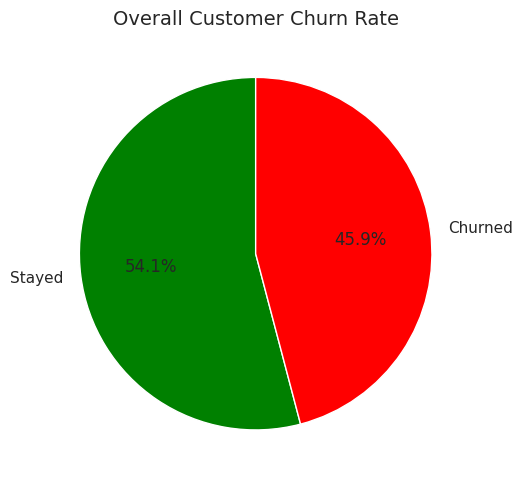

Total customers: 36,992
Churned: 20,012 (54.1%)
Stayed: 16,980 (45.9%)


In [57]:
plt.figure(figsize=(6, 5))
churn_labels = ['Stayed', 'Churned']
churn_counts = df['churn_risk_score'].value_counts()
colors = ['green', 'red']

plt.pie(churn_counts, labels=churn_labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Overall Customer Churn Rate', fontsize=14)
plt.tight_layout()
plt.savefig('churn_rate.png', dpi=150)
plt.show()

print(f'Total customers: {len(df):,}')
print(f'Churned: {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)')
print(f'Stayed: {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)')

### 5.2 Does Membership Type Affect Churn?

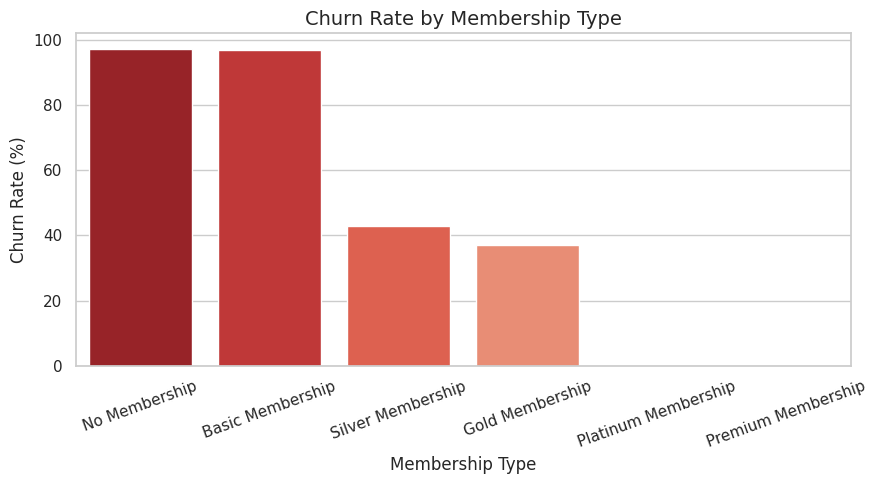

Churn rate per membership type:
  No Membership: 97.1%
  Basic Membership: 96.8%
  Silver Membership: 42.8%
  Gold Membership: 37.0%
  Platinum Membership: 0.0%
  Premium Membership: 0.0%


In [60]:
# Calculate churn rate per membership type
membership_churn = df.groupby('membership_category', observed=False)['churn_risk_score'].mean() * 100
membership_churn = membership_churn.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=membership_churn.index, y=membership_churn.values,
            hue=membership_churn.index, palette='Reds_r', legend=False)
plt.title('Churn Rate by Membership Type', fontsize=14)
plt.xlabel('Membership Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('churn_by_membership.png', dpi=150)
plt.show()

print('Churn rate per membership type:')
for m, v in membership_churn.items():
    print(f'  {m}: {v:.1f}%')

### 5.3 What Age Group Churns the Most?

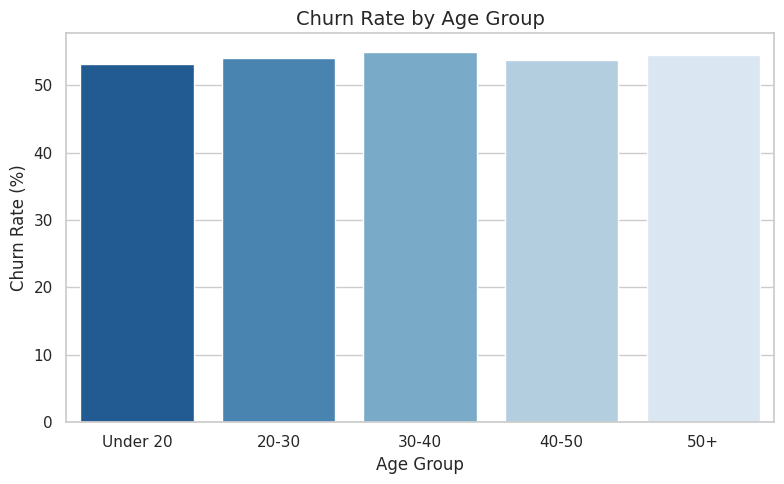

Churn rate per age group:
  Under 20: 53.2%
  20-30: 54.1%
  30-40: 55.0%
  40-50: 53.7%
  50+: 54.5%


In [61]:
# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 65],
                          labels=['Under 20', '20-30', '30-40', '40-50', '50+'])

age_churn = df.groupby('age_group', observed=False)['churn_risk_score'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=age_churn.index, y=age_churn.values,
            hue=age_churn.index, palette='Blues_r', legend=False)
plt.title('Churn Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('churn_by_age.png', dpi=150)
plt.show()

print('Churn rate per age group:')
for age, val in age_churn.items():
    print(f'  {age}: {val:.1f}%')

### 5.4 Do Customers With Complaints Churn More?

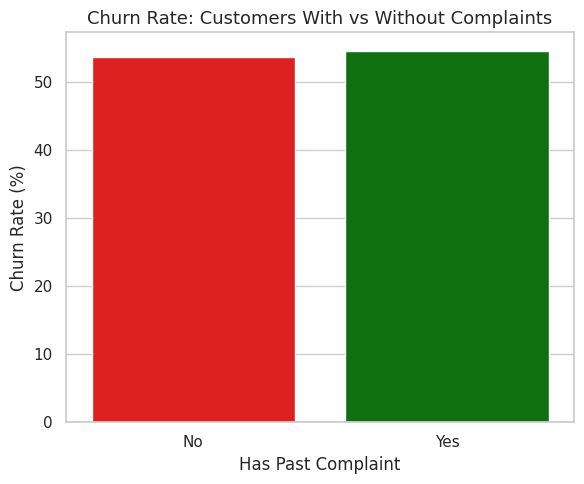

Churn rate by complaint status:
  No: 53.7%
  Yes: 54.5%


In [65]:
complaint_churn = df.groupby('past_complaint', observed=False)['churn_risk_score'].mean() * 100

plt.figure(figsize=(6, 5))
sns.barplot(x=complaint_churn.index, y=complaint_churn.values,
            hue=complaint_churn.index,
            palette={'Yes': 'green', 'No': 'red'},
            legend=False)
plt.title('Churn Rate: Customers With vs Without Complaints', fontsize=13)
plt.xlabel('Has Past Complaint')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('churn_by_complaint.png', dpi=150)
plt.show()

print('Churn rate by complaint status:')
for c, v in complaint_churn.items():
    print(f'  {c}: {v:.1f}%')

### 5.5 Which Region Has the Highest Churn?

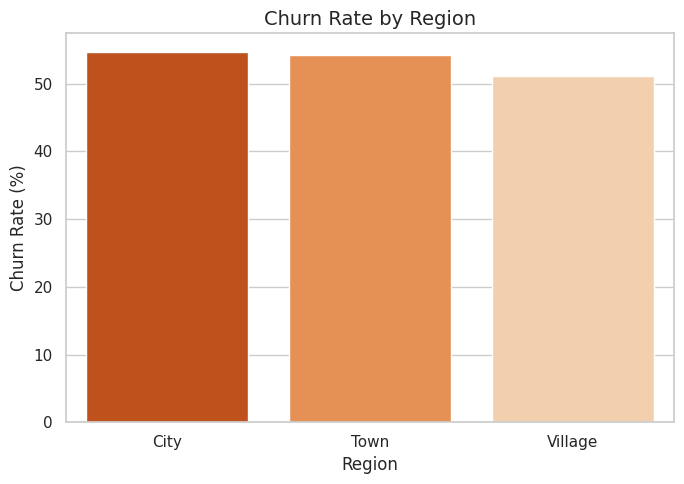

Churn rate per region:
  City: 54.7%
  Town: 54.2%
  Village: 51.2%


In [63]:
region_churn = df[df['region_category'] != 'Unknown'].groupby(
    'region_category', observed=False)['churn_risk_score'].mean() * 100
region_churn = region_churn.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=region_churn.index, y=region_churn.values,
            hue=region_churn.index, palette='Oranges_r', legend=False)
plt.title('Churn Rate by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('churn_by_region.png', dpi=150)
plt.show()

print('Churn rate per region:')
for r, v in region_churn.items():
    print(f'  {r}: {v:.1f}%')

### 5.6 What Feedback Do Churned Customers Leave?

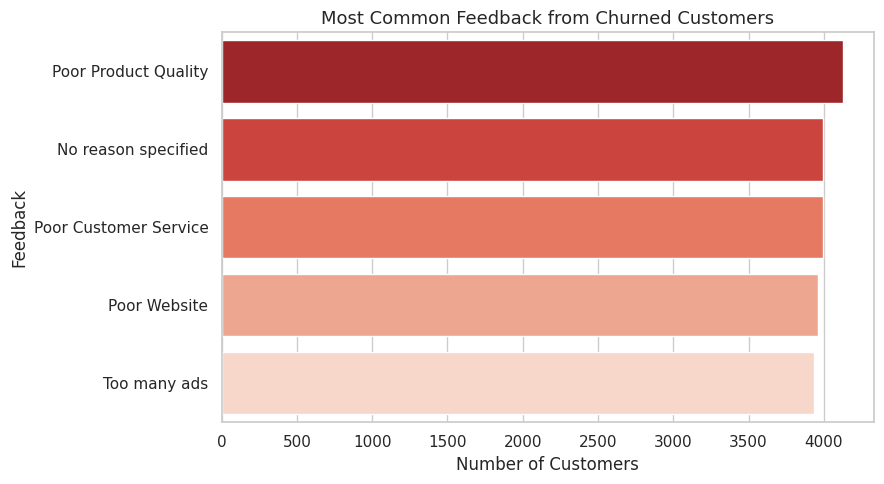

In [64]:
churned_feedback = df[df['churn_risk_score'] == 1]['feedback'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=churned_feedback.values, y=churned_feedback.index,
            hue=churned_feedback.index, palette='Reds_r', legend=False)
plt.title('Most Common Feedback from Churned Customers', fontsize=13)
plt.xlabel('Number of Customers')
plt.ylabel('Feedback')
plt.tight_layout()
plt.savefig('churn_feedback.png', dpi=150)
plt.show()

## 6. Summary & Conclusion

Here's what we found from our customer churn analysis:

- **Overall churn rate** is around 54%, meaning more than half of customers are at risk of leaving.

- **Membership type matters** — customers with No Membership or Basic Membership churn at a much higher rate than Platinum or Gold members.

- **Younger customers** tend to churn more than older ones, suggesting loyalty increases with age.

- **Customers with past complaints** are significantly more likely to churn, thereby resolving complaints quickly is key to retention.

- **Poor Product Quality and Poor Customer Service** are the most common reasons churned customers give as feedback.

These insights suggest the company should focus on improving product quality, resolving complaints faster, and offering better incentives to Basic and No Membership customers to encourage upgrades.